In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"]     = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"]       = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]  = os.getenv("LANGSMITH_API_KEY")   
os.environ["LANGSMITH_TRACING"]  = "false"                           
os.environ["LANGSMITH_ENDPOINT"] = "https://eu.api.smith.langchain.com"  
os.environ["USER_AGENT"]         = "self-rag/1.0"                    

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")   
llm = ChatGroq(model="llama-3.3-70b-versatile")                     

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3122.18it/s]


In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(docs_list)

vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embeddings,
)

retriever = vectorstore.as_retriever()

In [5]:
from langchain_core.tools.retriever import create_retriever_tool   

retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_blog_posts",
    "Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.",
)

tools = [retriever_tool]

#### Retrieval grader

In [6]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field                     

class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

In [7]:
structured_llm_grader = llm.with_structured_output(GradeDocuments)

system = """You are a grader checking if a document is relevant to a user's question. The check has to be done very strictly.
If the document has words or meanings related to the question, mark it as relevant.
Give a simple 'yes' or 'no' answer to show if the document is relevant or not."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

my_retrieval_grader = grade_prompt | structured_llm_grader

In [8]:
question = "what is ai agent?"
docs = retriever.invoke(question)                         
doc_txt = docs[2].page_content
print(my_retrieval_grader.invoke({"document": doc_txt, "question": question}))

binary_score='yes'


In [9]:
question = "who is prakadeesh?"
print(my_retrieval_grader.invoke({"document": doc_txt, "question": question}))

binary_score='no'


### Generation

In [10]:
from langchain_core.output_parsers import StrOutputParser


prompt = ChatPromptTemplate.from_messages([
    ("human", """You are an assistant for question-answering tasks.
    Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know.
    Use three sentences maximum and keep the answer concise.

    Question: {question}
    Context: {context}
    Answer:""")
    ])

rag_chain = prompt | llm

In [11]:
question = "what is a AI agent?"
generation = rag_chain.invoke({"context": docs, "question": question})
generation

AIMessage(content="An AI agent is a system that uses a large language model (LLM) as its core controller, complemented by key components such as planning, memory, and tool use. The LLM functions as the agent's brain, enabling it to break down complex tasks into smaller subgoals, learn from mistakes, and refine its actions. In a LLM-powered autonomous agent system, the agent can plan ahead, utilize short-term and long-term memory, and call external APIs for extra information.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 99, 'prompt_tokens': 1930, 'total_tokens': 2029, 'completion_time': 0.214382948, 'completion_tokens_details': None, 'prompt_time': 0.10251419, 'prompt_tokens_details': None, 'queue_time': 0.041764521, 'total_time': 0.316897138}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2264-b20a-7a00-8

### Hallucination Grader

In [12]:
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""
    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

structured_llm_grader = llm.with_structured_output(GradeHallucinations)

system = """You are a grader checking if an LLM generation is grounded in or supported by a set of retrieved facts.
Give a simple 'yes' or 'no' answer. 'Yes' means the generation is grounded in or supported by a set of retrieved facts."""

hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucinations_grader = hallucination_prompt | structured_llm_grader
print(hallucinations_grader.invoke({"documents": docs, "generation": generation}))

binary_score='yes'


#### Answer Grader

In [13]:
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""
    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )

structured_llm_grader = llm.with_structured_output(GradeAnswer)

system = """You are a grader assessing whether an answer addresses / resolves a question.
Give a binary score 'yes' or 'no'. 'Yes' means that the answer resolves the question."""

answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
print(answer_grader.invoke({"question": question, "generation": generation}))

binary_score='yes'


### Question Re-writer

In [14]:
system = """You are a question re-writer that converts an input question into a better optimized version for vector store retrieval document.
You are given both a question and a document.
- First, check if the question is relevant to the document by identifying a connection or relevance between them.
- If there is a little relevancy, rewrite the question based on the semantic intent of the question and the context of the document. Keep it concise, under 100 words.
- If no relevance is found, simply return this single word "question not relevant." dont return the entire phrase
Your goal is to ensure the rewritten question aligns well with the document for better retrieval."""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human", """Here is the initial question: \n\n {question} \n,
             Here is the document: \n\n {documents} \n ,
             Formulate an improved question. if possible other return 'question not relevant'."""
        ),
    ]
)
question_rewriter = re_write_prompt | llm | StrOutputParser()

In [15]:
question = "who is a current indian prime minister?"
question_rewriter.invoke({"question": question, "documents": docs})

'question not relevant'

In [16]:
from typing import List
from typing_extensions import TypedDict

class AgentState(TypedDict):
    question: str
    generation: str
    documents: List[str]
    filter_documents: List[str]
    unfilter_documents: List[str]

In [17]:
def retrieve(state: AgentState):
    print("----RETRIEVE----")
    question = state["question"]
    documents = retriever.invoke(question)               
    return {"documents": documents, "question": question}

In [18]:
def grade_documents(state: AgentState):
    print("----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----")
    question = state["question"]
    documents = state["documents"]

    filtered_docs = []
    unfiltered_docs = []
    for doc in documents:
        score = my_retrieval_grader.invoke({"question": question, "document": doc})
        grade = score.binary_score

        if grade == "yes":
            print("----GRADE: DOCUMENT RELEVANT----")
            filtered_docs.append(doc)
        else:
            print("----GRADE: DOCUMENT NOT RELEVANT----")
            unfiltered_docs.append(doc)

    if len(unfiltered_docs) > 1:
        return {"unfilter_documents": unfiltered_docs, "filter_documents": [], "question": question}
    else:
        return {"filter_documents": filtered_docs, "unfilter_documents": [], "question": question}

In [19]:
def decide_to_generate(state: AgentState):
    print("----ACCESS GRADED DOCUMENTS----")
    unfiltered_documents = state["unfilter_documents"]
    filtered_documents = state["filter_documents"]

    if unfiltered_documents:
        print("----ALL THE DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY----")
        return "transform_query"
    if filtered_documents:
        print("----DECISION: GENERATE----")
        return "generate"

In [20]:
def generate(state: AgentState):
    print("----GENERATE----")
    question = state["question"]
    documents = state["documents"]

    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

In [21]:
def transform_query(state: AgentState):
    print("----TRANSFORM QUERY----")
    question = state["question"]
    documents = state["documents"]

    response = question_rewriter.invoke({"question": question, "documents": documents})
    print(f"----REWRITTEN QUESTION---- {response}")
    if response == "question not relevant":
        print("----QUESTION IS NOT AT ALL RELEVANT----")
        return {"documents": documents, "question": response, "generation": "question was not at all relevant"}
    else:
        return {"documents": documents, "question": response}

In [22]:
def decide_to_generate_after_transformation(state: AgentState):
    question = state["question"]

    if question == "question not relevant":
        return "query_not_at_all_relevant"
    else:
        return "Retriever"

In [23]:
def grade_generation_vs_documents_and_question(state: AgentState):
    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucinations_grader.invoke({"documents": documents, "generation": generation})
    grade = score.binary_score

    # Check hallucinations
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")

        print("---GRADE GENERATION vs QUESTION ---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score

        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES THE QUESTION ---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS THE QUESTION, RE-TRY---TRANSFORM QUERY")
            return "not useful"
    else:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---TRANSFORM QUERY")   # fixed: was pprint(...) which crashes (pprint is a module)
        return "not useful"                                                                        # fixed: was missing return — router returned None and graph crashed

### LangGraph workflow

In [24]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(AgentState)
workflow.add_node("Docs_Vector_Retrieve", retrieve)
workflow.add_node("Grading_Generated_Documents", grade_documents)
workflow.add_node("Content_Generator", generate)
workflow.add_node("Transform_User_Query", transform_query)

In [25]:
workflow.add_edge(START, "Docs_Vector_Retrieve")
workflow.add_edge("Docs_Vector_Retrieve", "Grading_Generated_Documents")

workflow.add_conditional_edges(
    "Grading_Generated_Documents",
    decide_to_generate,
    {
        "generate": "Content_Generator",
        "transform_query": "Transform_User_Query",
    }
)

workflow.add_conditional_edges(
    "Content_Generator",
    grade_generation_vs_documents_and_question,
    {
        "useful": END,
        "not useful": "Transform_User_Query",
    }
)

workflow.add_conditional_edges(
    "Transform_User_Query",
    decide_to_generate_after_transformation,
    {
        "Retriever": "Docs_Vector_Retrieve",
        "query_not_at_all_relevant": END,
    }
)

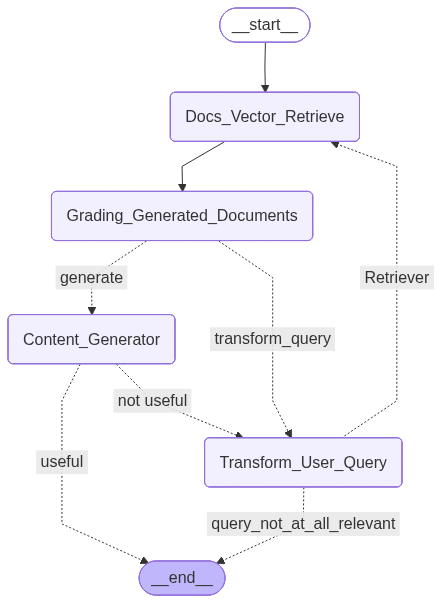

In [26]:
app = workflow.compile()

from IPython.display import Image, display
try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print(e)

In [27]:
inputs = {"question": "Explain how the different types of agent memory work?"}
app.invoke(inputs)["generation"]

----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----ACCESS GRADED DOCUMENTS----
----DECISION: GENERATE----
----GENERATE----
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION ---
---DECISION: GENERATION ADDRESSES THE QUESTION ---


AIMessage(content="There are two types of agent memory: short-term memory and long-term memory. Short-term memory utilizes in-context learning, allowing the model to learn from prompts, while long-term memory retains and recalls information over extended periods using an external vector store and fast retrieval. Long-term memory can be implemented through a memory stream, which records agents' experiences in natural language, and a retrieval model that surfaces relevant context to inform the agent's behavior.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 1982, 'total_tokens': 2070, 'completion_time': 0.270009927, 'completion_tokens_details': None, 'prompt_time': 0.178156331, 'prompt_tokens_details': None, 'queue_time': 0.040805713, 'total_time': 0.448166258}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq

In [28]:
inputs = {"question": "who is a prompt engineering?"}
app.invoke(inputs)["generation"]

----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----ACCESS GRADED DOCUMENTS----
----DECISION: GENERATE----
----GENERATE----
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION ---
---DECISION: GENERATION ADDRESSES THE QUESTION ---


AIMessage(content='Prompt engineering refers to methods for communicating with large language models (LLMs) to steer their behavior for desired outcomes without updating the model weights. It is an empirical science that requires heavy experimentation and heuristics, and its effects can vary among models. The goal of prompt engineering is about alignment and model steerability, particularly for autoregressive language models.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 1079, 'total_tokens': 1151, 'completion_time': 0.160064941, 'completion_tokens_details': None, 'prompt_time': 0.083841341, 'prompt_tokens_details': None, 'queue_time': 0.041570441, 'total_time': 0.243906282}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2265-350b-70c2-8db0-cbc3df8f8201-0', tool_calls=[], invalid_tool_

In [29]:
inputs = {"question": "what is role of c language and php while creating ai agentic pattern?"}
app.invoke(inputs)

----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----ACCESS GRADED DOCUMENTS----
----ALL THE DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY----
----TRANSFORM QUERY----
----REWRITTEN QUESTION---- What role do programming languages play in building LLM-powered autonomous agents?
----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----ACCESS GRADED DOCUMENTS----
----ALL THE DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY----
----TRANSFORM QUERY----
----REWRITTEN QUESTION---- How do programming languages interact with LLMs in autonomous agents for tasks like code execution and problem-solving?
----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION---

{'question': 'How do programming languages interact with LLMs in autonomous agents for tasks like code execution and problem-solving?',
 'generation': AIMessage(content='Programming languages interact with LLMs in autonomous agents through various methods, such as generating programming language statements to resolve natural language reasoning problems, which can be executed by a runtime like a Python interpreter. The agent can also learn to call external APIs for code execution capability, allowing it to access and utilize programming languages. This integration enables the agent to leverage the strengths of both LLMs and programming languages for tasks like problem-solving.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 1802, 'total_tokens': 1888, 'completion_time': 0.286699265, 'completion_tokens_details': None, 'prompt_time': 0.1144507, 'prompt_tokens_details': None, 'queue_time': 0.042603538, 'total_time': 0.401149965}, 'model_

In [30]:
inputs = {"question": "who is a first president of USA?"}
app.invoke(inputs)["generation"]

----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----ACCESS GRADED DOCUMENTS----
----ALL THE DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY----
----TRANSFORM QUERY----
----REWRITTEN QUESTION---- question not relevant.
----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----ACCESS GRADED DOCUMENTS----
----ALL THE DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY----
----TRANSFORM QUERY----
----REWRITTEN QUESTION---- question not relevant.
----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----

'question was not at all relevant'